# 非程式題

1. 如果 Agent 沒有 planning 能力會有什麼缺點？
  > 瞎搞
  
  > 想到什麼做什麼，容易偏離主題，並且執行時間可能因序列執行導致作業時間過長。

2. planning 在實務應用上會碰到什麼困難？

  > 任務與計畫方法的特性衝突，可能需要針對不同任務類型有不同計畫方法

  > 可能會因過度計畫而導致成本暴增、效率下降或是無限迴圈。

# 程式題

In [1]:
!pip install --quiet -U langgraph langchain-openai langchain-community tavily-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 440.2/440.2 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.5/216.5 kB 11.6 MB/s eta 0:00:00


## 將下列的小工具加進你的 plan-and-execute agent 裡面，使得輸出類似的結果

> 小小 hint：tutorial 照摳就好好🙂，或是大家可以自己寫一些 function 或是找一些外部 api 工具，玩一下看看有什麼新花樣

In [2]:
import requests
import pandas as pd
from langchain_core.tools import tool

@tool
def getMainBuyAndSale() :
  """台積電股價及其他相關資訊"""
  url = f'https://pchome.megatime.com.tw/stock/sto1/ock4/sid' + '2330' + '.html'
  payloads = {'is_check': '1'}
  resp = requests.request(method='POST', url=url, data=payloads)
  data = pd.read_html(resp.text)

  return data

In [4]:
import os
from google.colab import userdata

os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
os.environ["TAVILY_API_KEY"] = userdata.get('TAVILY_API_KEY')

In [5]:
from langchain_core.tools import tool
import datetime
from langchain_community.tools.tavily_search import TavilySearchResults

@tool
def get_current_date() -> str:
    """取得現在的日期，格式為 YYYY-MM-DD"""
    return datetime.datetime.now().strftime("%Y-%m-%d")

tools = [
    TavilySearchResults(max_results=3),
    get_current_date
    ]


/tmp/ipython-input-5-1724882765.py:11: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-tavily package and should be used instead. To use it run `pip install -U :class:`~langchain-tavily` and import as `from :class:`~langchain_tavily import TavilySearch``.
  TavilySearchResults(max_results=3),


In [22]:
import os
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import create_react_agent

# 建議把 OPENROUTER_API_KEY 寫在 .env 或 CI 祕密變數

# 1) 先設定 llm、tools、prompt
llm = ChatOpenAI(
    model="mistralai/mistral-small-3.1-24b-instruct:free",
    base_url="https://openrouter.ai/api/v1",
    openai_api_key=os.getenv("OPENAI_API_KEY"),
    temperature=0,
)
prompt = "你是一個專業等級的任務執行器，用來完美執行任務計劃。"

# 2) 只給 2 個位置參數；prompt 改成關鍵字
agent_executor = create_react_agent(
    llm,          # ← 第 1 個位置參數：model
    tools,        # ← 第 2 個位置參數：tools
    prompt=prompt # ← 關鍵字參數
    # debug=True
)


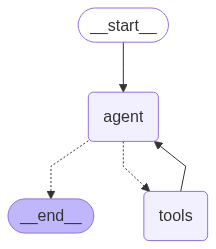

In [23]:

from IPython.display import Image, display

display(Image(agent_executor.get_graph(xray=True).draw_mermaid_png()))


In [24]:
agent_executor.invoke({"messages": [("user", "今天幾號？")]})

{'messages': [HumanMessage(content='今天幾號？', additional_kwargs={}, response_metadata={}, id='e387a6e8-0470-452a-bbdf-00279bf2db36'),
  AIMessage(content='[{"name": "get_current_date", "arguments": {}}]', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 188, 'total_tokens': 205, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_name': 'mistralai/mistral-small-3.1-24b-instruct:free', 'system_fingerprint': None, 'id': 'gen-1751445689-8Po1LTq37qJ8Ej6hMqPV', 'service_tier': None, 'finish_reason': 'stop', 'logprobs': None}, id='run--b10319aa-5cca-479d-96f0-c4d9537d8906-0', usage_metadata={'input_tokens': 188, 'output_tokens': 17, 'total_tokens': 205, 'input_token_details': {}, 'output_token_details': {}})]}

In [25]:
import operator
from typing import Annotated, List, Tuple
from typing_extensions import TypedDict


class PlanExecute(TypedDict):
    input: str
    plan: List[str] # 待執行的步驟
    past_steps: Annotated[List[Tuple], operator.add] # 執行步驟後的結果
    response: str # 最終的問題回覆結果

In [26]:
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field

class Plan(BaseModel):
    """未來要遵循的計劃"""

    steps: List[str] = Field(description="不同的步驟，應按順序排列")

planner_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """
            你是一個專業等級的任務規劃器。
            請根據指定目標，擬定一份簡潔的逐步執行計畫。
            此計畫應包含一系列獨立的任務，每個任務若正確執行，將逐步導向正確的答案。
            請避免加入任何多餘的步驟。
            最終步驟的執行結果即為最終答案。
            請確保每個步驟皆包含完成所需的所有資訊，不得跳過任何必要步驟。
            """,
        ),
        ("placeholder", "{messages}"),
    ]
)


In [27]:
planner = planner_prompt | ChatOpenAI(
    model="mistralai/mistral-small-3.1-24b-instruct:free",
    base_url="https://openrouter.ai/api/v1",
    openai_api_key=os.getenv("OPENAI_API_KEY"),
    temperature=0,
).with_structured_output(Plan)

In [28]:
planner.invoke(
    {
        "messages": [
            ("user", "今天適合將新台幣兌換成日圓嗎？只根據今天日期及今天過去30天的平均匯率做判斷。")
        ]
    }
)

Plan(steps=['step1: 確認今天的日期', 'step2: 獲取過去30天的新台幣兌換日圓的平均匯率', 'step3: 獲取今天的新台幣兌換日圓的即時匯率', 'step4: 比較今天的即時匯率與過去30天的平均匯率', 'step5: 如果今天的即時匯率高於過去30天的平均匯率，則今天適合兌換；反之，則不適合兌換'])

In [29]:
from typing import Union


class Response(BaseModel):
    """回應使用者的內容"""

    response: str


class Act(BaseModel):
    """要執行的動作"""

    action: Union[Response, Plan] = Field(
        description="要執行的動作： 若要回應使用者，請使用'Response'。"
        "若需進一步使用工具以取得答案，請使用'Plan'。"
    )

replanner_prompt = ChatPromptTemplate.from_template(
    """
    你是一個專業等級的任務規劃器。
    請根據指定目標，擬定一份簡潔的逐步執行計畫。
    此計畫應包含一系列獨立的任務，每個任務若正確執行，將逐步導向正確的答案。
    請避免加入任何多餘的步驟。
    最終步驟的執行結果即為最終答案。
    請確保每個步驟皆包含完成所需的所有資訊，不得跳過任何必要步驟。

    本次任務的目標為：
    {input}

    你原先擬定的計畫為：
    {plan}

    目前已執行的步驟如下：
    {past_steps}

    請根據目前進度，調整後續的執行計畫。
    若已無需進一步步驟，並可直接回應使用者，請進行回應；
    若仍需執行工具或任務取得答案，請補足剩餘計畫。
    請僅列出尚未完成且仍需執行的步驟，勿重複列出已執行的部分。
    """
)

In [30]:
replanner = replanner_prompt | ChatOpenAI(
    model="mistralai/mistral-small-3.1-24b-instruct:free",
    base_url="https://openrouter.ai/api/v1",
    openai_api_key=os.getenv("OPENAI_API_KEY"),
    temperature=0,
).with_structured_output(Act)

In [31]:
from langgraph.graph import END


# 執行計劃中的第一個步驟
async def execute_step(state: PlanExecute):
    plan = state["plan"]
    # 將所有步驟編號整理成文字（用於提示）
    plan_str = "\n".join(f"{i+1}. {step}" for i, step in enumerate(plan))
    task = plan[0] # 抓出第一個尚未執行的步驟
    task_formatted = f"""針對以下計劃：{plan_str}\n\n你的任務是執行 step {1}, {task}."""

    # 呼叫執行器執行該步驟
    agent_response = await agent_executor.ainvoke(
        {"messages": [("user", task_formatted)]}
    )

    # 回傳本次執行結果（步驟與回應）
    return {
        "past_steps": [(task, agent_response["messages"][-1].content)],
    }

# 初始規劃流程
async def plan_step(state: PlanExecute):
    plan = await planner.ainvoke({"messages": [("user", state["input"])]})
    return {"plan": plan.steps}

# 根據已完成的步驟與整體輸入，更新後續步驟或直接產生答案。
async def replan_step(state: PlanExecute):
    output = await replanner.ainvoke(state)

    # 若模型決定可以直接回覆使用者（任務結束），則回傳結果
    if isinstance(output.action, Response):
        return {"response": output.action.response}
    else:
        # 否則更新剩餘計劃
        return {"plan": output.action.steps}

# 檢查是否已經產生最終回應，決定是否結束流程
def should_end(state: PlanExecute):
    if "response" in state and state["response"]:
        return END
    else:
        return "executor"

In [33]:
from langgraph.graph import StateGraph, START

graph_builder = StateGraph(PlanExecute)

graph_builder.add_node("planner", plan_step) # 新增規劃器節點
graph_builder.add_node("executor", execute_step) # 新增執行器節點
graph_builder.add_node("replanner", replan_step) # 新增重新規劃器節點

graph_builder.add_edge(START, "planner")
graph_builder.add_edge("planner", "executor") # 將規劃器與執行器連接
graph_builder.add_edge("executor", "replanner") # 將執行器與重新規劃器連接

graph_builder.add_conditional_edges(
    "replanner",
    should_end,
    ["executor", END],
)

graph = graph_builder.compile()

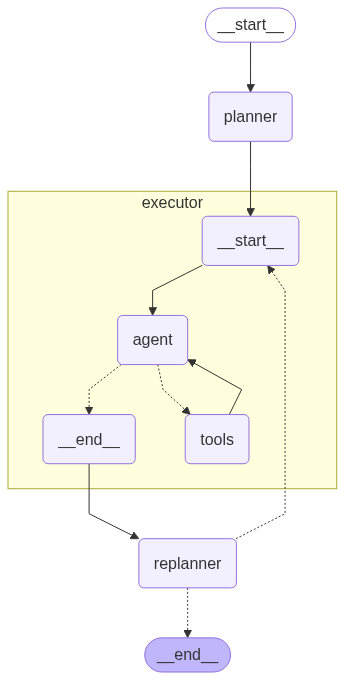

In [34]:
from IPython.display import Image, display

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [35]:
from langchain_core.callbacks.base import BaseCallbackHandler

class PrintToolNameHandler(BaseCallbackHandler):
    def on_tool_start(self, serialized_tool: dict, input_str, **kwargs):
        tool_name = serialized_tool.get("name", "")
        print(f"[Tool name] {tool_name}")

In [36]:
config = {"recursion_limit": 50,
          "callbacks":[PrintToolNameHandler()]}
inputs = {"input": "明天適合進場台積電嗎?"}

async for event in graph.astream(inputs, config=config):
    for k, v in event.items():
        if k != "__end__":
            for step in v.keys():
              if step == "plan":
                print(f"[{step}]")
                for idx, action in enumerate(v[step]):
                  print(f"{idx+1}. {action}")

              elif step == "past_steps":
                print(f"[{step}]")
                for action in v[step][0]:
                  print(action)

              else:
                print(f"[{step}]")
                print(v[step])
    print('\n')

[plan]
1. step1: 確認台積電的最新財務報告
2. step2: 分析台積電的財務狀況，包括收入、利潤、現金流等
3. step3: 研究台積電的市場地位和競爭優勢
4. step4: 了解台積電的最新技術發展和產品管線
5. step5: 分析台積電的股價走勢和技術指標
6. step6: 參考市場分析師和專家的最新評論和預測
7. step7: 評估全球經濟環境和半導體行業的趨勢
8. step8: 綜合以上資訊，判斷台積電的投資價值和風險
9. step9: 根據個人投資目標和風險承受能力，決定是否進場


[past_steps]
step1: 確認台積電的最新財務報告
[{"name": "tavily_search_results_json", "arguments": {"query": "台積電最新財務報告"}}]


[plan]
1. step2: 分析台積電的財務狀況，包括收入、利潤、現金流等
2. step3: 研究台積電的市場地位和競爭優勢
3. step4: 了解台積電的最新技術發展和產品管線
4. step5: 分析台積電的股價走勢和技術指標
5. step6: 參考市場分析師和專家的最新評論和預測
6. step7: 評估全球經濟環境和半導體行業的趨勢
7. step8: 綜合以上資訊，判斷台積電的投資價值和風險
8. step9: 根據個人投資目標和風險承受能力，決定是否進場


[Tool name] tavily_search_results_json
[past_steps]
step2: 分析台積電的財務狀況，包括收入、利潤、現金流等
以下是針對台積電財務狀況的分析：

### 1. 營業收入
根據[嗨投資](https://histock.tw/stock/2330/%E8%B2%A1%E5%8B%99%E5%A0%B1%E8%A1%A8)的數據，台積電的營業收入在2023年有顯著的波動。例如，2023年1月的營業收入為200,050,496千元，而2023年2月則下降至163,174,096千元。這些數據顯示出台積電的營業收入在不同月份之間有較大的變動。

### 2. 獲利能力
根據[MoneyDJ理財網](https://www.moneydj.com/Z/ZC/ZCA/ZCA.djhtm?a=2330

TypeError: 'NoneType' object is not iterable